<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_dl.png">


<br><br><center><h1 style="font-size:2em;color:#2467C0"> Operaciones lógicas y máscaras </h1></center>
<br>
<table>
<col width="550">
<col width="450">
<tr>
    
    
<td><img src="figuras/openCV.jpg" align="middle" style="width:550px;"/></td>
<td>

**OpenCV** es una biblioteca libre desarrollada originalmente por Intel. Vio la luz en el año 1999. Escrita originalmente en C/C++, su mejor virtud es que es multiplataforma, se puede ejecutar en diferentes sistemas operativos (Linux, Windows, Mac OS X, Android e iOS). También la podemos utilizar en diferentes lenguajes de programación como Java, Objective C, C# y *Python*.

Quizás sea la biblioteca de visión artificial más importante y más usada. Es utilizada por universidades, empresas y gente del movimiento Maker para dar rienda suelta a su imaginación al tratarse de un software libre.

En este notebook comenzaremos con el tratamiento de imágenes en Python mediante esta librería, más específicamente vamos a ver como cargar o  leer una imagen, conversión a blanco y negro, filtros y otras operaciones que serán útiles dentro del curso.


   
<br>
</td>
</tr>
</table>

# 0. Librerías básicas

In [1]:
#Librerías básicas de esta notebook
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

# TAREA 

<div class="alert alert-success">
    
**Ejercicio 1**
    
 <ul>     
  <li>a) Generar imagenes como las que se muestran a continuación (300 x 300)</li>
  <li>b) Aplicar las operaciones de AND, OR y XOR</li>
   <li>b)Aplicar la operación inversa a ambas imagenes</li>     
</ul> 

</div>
<img align="left" width="500"  float= "none" align="middle" src="figuras/circulo_triangulo.png">


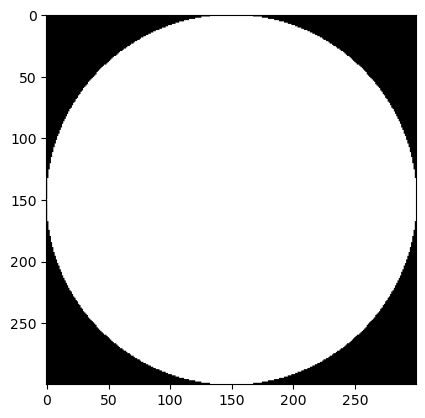

In [2]:
circulo =  np.zeros((300,300), dtype='uint8')
cv.circle(circulo, center=(150,150), radius=150, color=255, thickness=-1)
plt.imshow(circulo, cmap='gray')
plt.show()

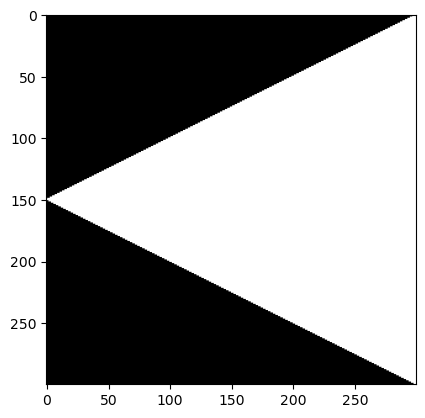

In [3]:
triangulo =  np.zeros((300,300), dtype='uint8')
pts = np.array([[0,150], [300,0], [300, 300]], np.int32)
cv.fillPoly(triangulo, pts=[pts], color=(255,255,255))
plt.imshow(triangulo, cmap='gray')
plt.show()

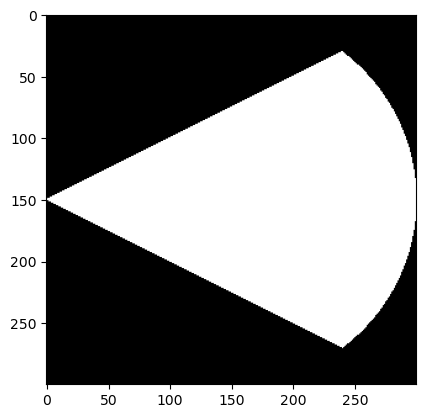

In [4]:
img_and = cv.bitwise_and(circulo, triangulo)

plt.imshow(img_and, cmap='gray')

plt.show()

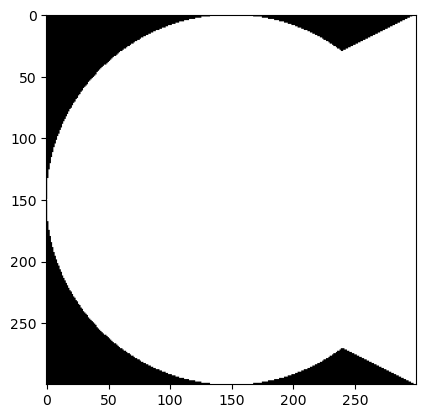

In [5]:
img_or = cv.bitwise_or(circulo, triangulo)

plt.imshow(img_or, cmap='gray')
plt.show()

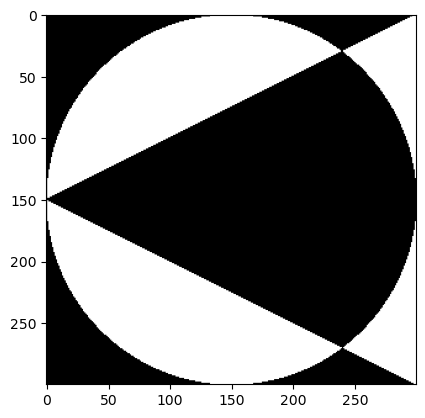

In [6]:
img_xor =  cv.bitwise_xor(circulo, triangulo)

plt.imshow(img_xor, cmap='gray')
plt.show()

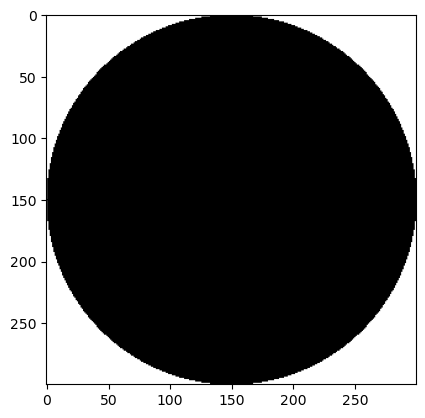

In [7]:
circulo_inv = cv.bitwise_not(circulo)
plt.imshow(circulo_inv, cmap='gray')
plt.show()

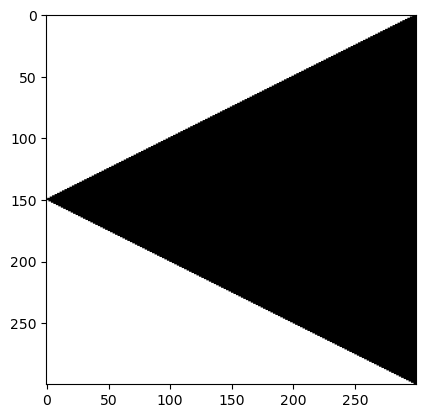

In [8]:
triangulo_inv =  cv.bitwise_not(triangulo)
plt.imshow(triangulo_inv, cmap='gray')
plt.show()

<div class="alert alert-success">
    
**Ejercicio 2.  Descargar una imagen con el rostro de una persona**
    
   
 <ul>
  <li>a) Generar y aplicar una mascara con una circunferencia </li>
  <li>b) Generar y aplicar una mascara con un cuadrado</li>
</ul> 

</div>


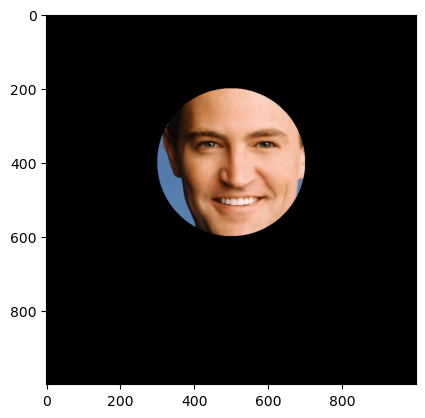

In [9]:
img = cv.imread('figuras/persona2.png')
img =  cv.cvtColor(img, cv.COLOR_BGR2RGB)
mascara_circulo = np.zeros(img.shape[:2], dtype='uint8')
cv.circle(mascara_circulo, center=(500,400), radius=200, color=(255,255,255), thickness=-1)

img_mascara = cv.bitwise_and(img, img, mask=mascara_circulo)

plt.imshow(img_mascara)
plt.show()

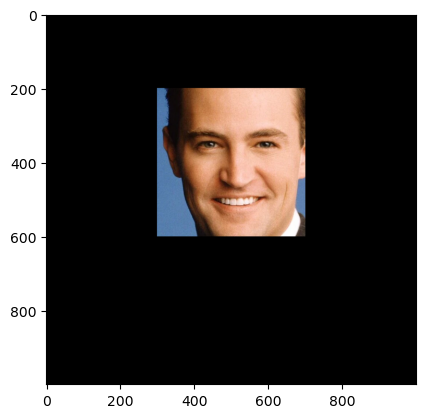

In [10]:
img = cv.imread('figuras/persona2.png')
img =  cv.cvtColor(img, cv.COLOR_BGR2RGB)
mascara_rectangulo = np.zeros(img.shape[:2], dtype='uint8')
cv.rectangle(mascara_rectangulo, pt1=(300,200),pt2=(700,600), color=(255,255,255), thickness=-1)
img_mascara = cv.bitwise_and(img, img, mask=mascara_rectangulo)

plt.imshow(img_mascara)
plt.show()

<div class="alert alert-success">
    
**Ejercicio 3**
    
   
 <ul>
  <li>a) Utilizando el archivo "figuras/ruido.jpg", aplicar todas las operaciones posibles para tratar de limpiar las letras de la figura del ruido existente, es decir tratar de que solo se vean las letras </li>
</ul> 

</div>
<img align="left" width="500"  float= "none" align="middle" src="figuras/ruido.jpg">

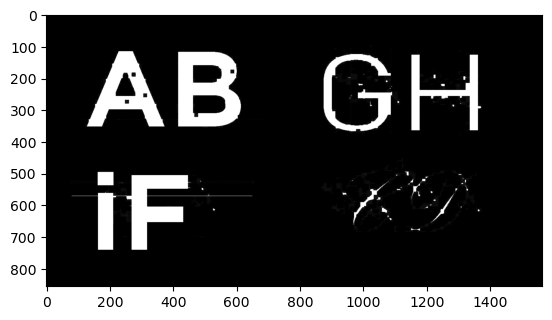

In [60]:
letras = cv.imread('figuras/ruido.jpg')
letras = cv.cvtColor(letras, cv.COLOR_BGR2GRAY)

kernel = cv.getStructuringElement(cv.MORPH_RECT, (4,4))
letras_fix = cv.bitwise_not(letras)
letras_fix = cv.dilate(letras_fix, None, iterations=3)
letras_fix = cv.morphologyEx(letras_fix, cv.MORPH_OPEN, kernel)
letras_fix = cv.erode(letras_fix, None, iterations=5)
#letras_fix = cv.morphologyEx(letras_fix, cv.MORPH_OPEN, kernel)

plt.imshow(letras_fix, cmap='gray')
plt.show()

In [12]:
NO HACER

SyntaxError: invalid syntax (1856918186.py, line 1)

<div class="alert alert-success">
    
**Ejercicio 4**
    
   
 <ul>
  <li> Utilizar una imagen que tenga algún objeto en color azul y obtenga una nueva imagen en donde todo lo azul este a color y el resto en escala de grises   </li>
</ul> 

</div>


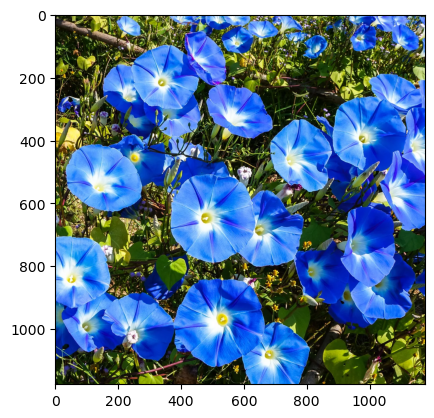

In [62]:
flores_azul = cv.imread('figuras/image.png')
flores_azul = cv.cvtColor(flores_azul, cv.COLOR_BGR2RGB)
plt.imshow(flores_azul)
plt.show()

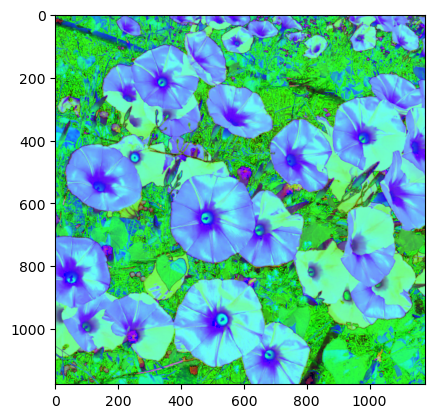

In [ ]:
flores_azul_hsv = cv.cvtColor(flores_azul, cv.COLOR_RGB2HSV)
plt.imshow(flores_azul_hsv)

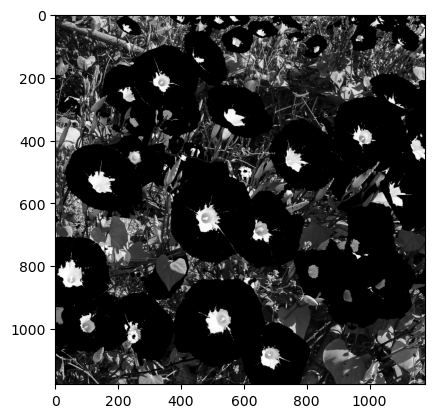

In [68]:
inferior = np.array([100,35,0])
superior = np.array([179,255,255])
mascara =  cv.inRange(flores_azul_hsv, inferior, superior)
flores_azul_gris = cv.cvtColor(flores_azul, cv.COLOR_RGB2GRAY)
flores_azul_sub = cv.subtract(flores_azul_gris, mascara)
flores_azul_sub = cv.cvtColor(flores_azul_sub, cv.COLOR_GRAY2RGB)
plt.imshow(flores_azul_sub, cmap='gray')

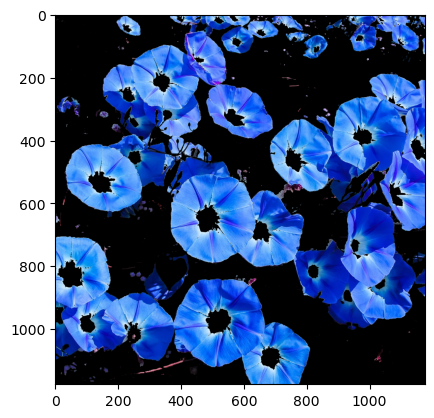

In [69]:
flores_mascara = cv.bitwise_and(flores_azul, flores_azul, mask=mascara)
plt.imshow(flores_mascara)

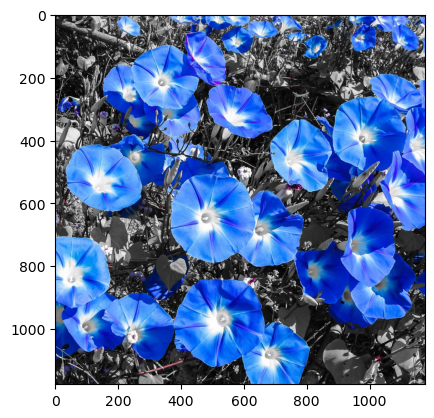

In [70]:
flores_final = cv.add(flores_azul_sub, flores_mascara)
plt.imshow(flores_final)